# Getting started with the PIKART atmospheric river datacube

A hands-on tour of the **PIKART v1.1 Eulerian Atmospheric River Catalog** on EarthCODE: a global, 0.5°, 6-hourly datacube of atmospheric rivers (ARs) over 1940–2023, with co-located ERA5 precipitation diagnostics.

By the end of this notebook you'll know how to:

1. Open the cube remotely from any Python environment
2. Inspect its structure and variables
3. Map where ARs occur globally
4. Look at a single AR event in space and time
5. Pull a time series at any location
6. Quantify how much ARs amplify extreme precipitation

**What's an atmospheric river?** Long, narrow corridors of intense water-vapor transport in the lower atmosphere — "rivers in the sky." A single major AR can carry more water than the Amazon. They produce a substantial fraction of the heavy-precipitation events on the US West Coast, Western Europe, Chile, New Zealand, and other midlatitude coasts, and they're a global driver of floods.

**Citation:** Vallejo-Bernal, S. M., Braun, T., Marwan, N., & Kurths, J. (2025). *PIKART: A comprehensive global catalog of atmospheric rivers.* JGR Atmospheres, 130, e2024JD041869. https://doi.org/10.1029/2024JD041869

**Documentation & full project info website:** https://ar.pik-potsdam.de

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

## 1. Open the datacube

The cube is published as a Zarr store on public S3 — anonymous read access, no credentials needed. xarray opens it lazily, so this is fast even on a laptop; data chunks are pulled over the network only when actually read.

> **Note:** update `CUBE_URL` if you're reading from a local copy or a mirror. The path below is the canonical EarthCODE location.

In [11]:
import os
import sys
import json
import numpy as np
import xarray as xr
import s3fs
import zarr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from xcube.core.store import new_data_store
import xrlint.all as xrl



OUTPUT_ID = "atmospheric_river_cube.zarr"


# --- Credentials ---
S3_KEY    = os.environ["S3_USER_STORAGE_KEY"]
S3_SECRET = os.environ["S3_USER_STORAGE_SECRET"]
S3_BUCKET = os.environ["S3_USER_STORAGE_BUCKET"]

# --- DeepESDL team bucket (destination) ---
fs = s3fs.S3FileSystem(anon=False, key=S3_KEY, secret=S3_SECRET)
bucket_path    = f"s3://{S3_BUCKET}"
output_mapper  = fs.get_mapper(f"{bucket_path}/{OUTPUT_ID}")

team_store = new_data_store(
    "s3", root=S3_BUCKET,
    storage_options=dict(anon=False, key=S3_KEY, secret=S3_SECRET),
)

ds = team_store.open_data(OUTPUT_ID)


In [ ]:
CUBE_URL = "s3://deep-esdl-public/atmospheric_river_cube.zarr"   # update if needed

ds = xr.open_zarr(
    CUBE_URL,
    storage_options={"anon": True},
    consolidated=True,
)
ds

The cube has **nine data variables** on a (time, lat, lon) grid:

| Group | Variable | Description |
|---|---|---|
| AR detection | `ar_mask` | Binary mask: 1 where an AR is present, 0 elsewhere |
| AR detection | `duration` | Duration of the AR event passing through this cell (hours) |
| AR detection | `intensity` | Peak IVT during the AR event (kg m⁻¹ s⁻¹) |
| AR detection | `rank` | AR rank (1–5) following Ralph et al. (2019) |
| Moisture transport | `ivt` | Vertically integrated water-vapor transport (kg m⁻¹ s⁻¹) |
| Precipitation | `tp` | 6-hour total precipitation from ERA5 (m) |
| Precipitation extremes | `epe_p90` | Binary flag: precipitation > 90th percentile |
| Precipitation extremes | `epe_p95` | Binary flag: precipitation > 95th percentile |
| Precipitation extremes | `epe_p99` | Binary flag: precipitation > 99th percentile |

The extreme-precipitation thresholds are computed *locally* (per grid cell), against a **1940–2024 baseline**, so `epe_p99=1` means *this cell's* precipitation exceeded *its own* 99th-percentile value — which means very different absolute precipitation amounts in different regions.

## 2. Where do atmospheric rivers occur?

The simplest climate-scale question: where are ARs most common? `ar_mask` summed over time gives the count of AR timesteps per cell. Dividing by the total number of timesteps converts that to a fraction (= AR frequency).

We'll start with a 20-year climatology (2000–2019) to keep the data transfer modest. 

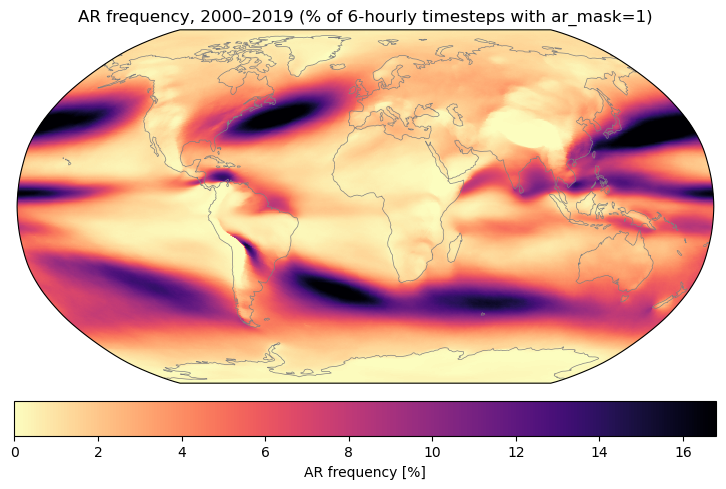

In [12]:
period = ds.sel(time=slice("2000", "2019"))
ar_freq = (period["ar_mask"].mean(dim="time")).compute() * 100   # percent of time

fig, ax = plt.subplots(figsize=(12, 5), subplot_kw={"projection": ccrs.Robinson()})
im = ax.pcolormesh(
    ar_freq.lon, ar_freq.lat, ar_freq.values,
    cmap="magma_r", shading="auto",
    vmin=0, vmax=np.nanpercentile(ar_freq.values, 99),
    transform=ccrs.PlateCarree(),
)
ax.coastlines(linewidth=0.5, color="gray")
ax.set_global()
plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.04, shrink=0.6, label="AR frequency [%]")
plt.tight_layout()
plt.show()

## 3. Exemplary single AR event

Let's look at one specific event: the AR that fed **Storm Desmond**, a strong storm that hit the UK and Ireland on 4–6 December 2015. The 5th Dec was peak landfall — Honister Pass in Cumbria recorded 341 mm of rain in 24 hours, then the all-time UK record.

We'll plot IVT (the moisture-transport field) and overlay the binary AR mask in white contours.

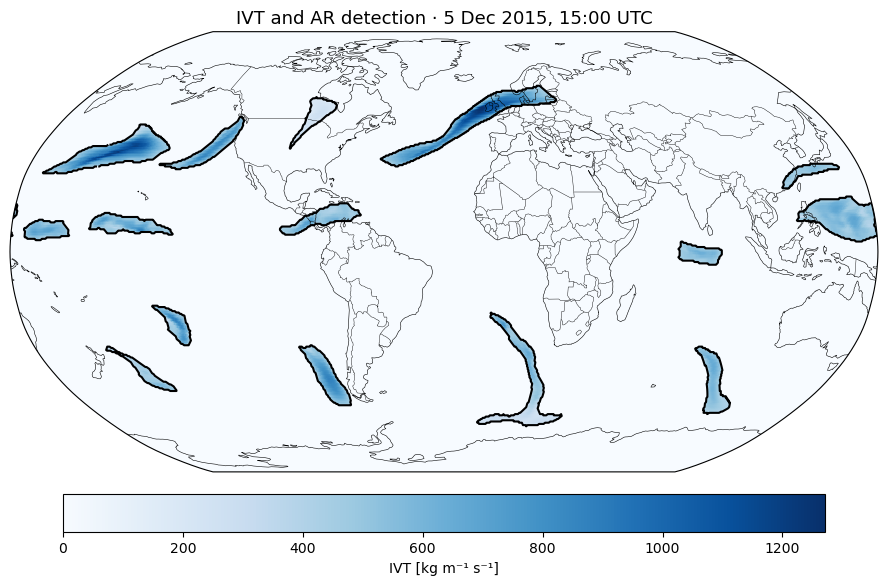

In [22]:
event = ds.sel(time="2015-12-05T15:00:00")

fig, ax = plt.subplots(figsize=(13, 6), subplot_kw={"projection": ccrs.Robinson(central_longitude=-30)})

# IVT field
im = ax.pcolormesh(
    event.lon, event.lat, event["ivt"].values,
    cmap="Blues", shading="auto",
    transform=ccrs.PlateCarree(),
)

# AR mask as white contour
ax.contour(
    event.lon, event.lat, event["ar_mask"].values,
    levels=[0.5], colors="black", linewidths=1.5,
    transform=ccrs.PlateCarree(),
)

ax.coastlines(linewidth=0.4, color="black")
ax.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor="black")
ax.set_global()
ax.set_title("IVT and AR detection · 5 Dec 2015, 15:00 UTC", fontsize=13)
plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.04, shrink=0.6,
             label="IVT [kg m⁻¹ s⁻¹]")
plt.tight_layout()
plt.show()

## 4. Time series at a coastal location

ARs are episodic — a region gets hit by one for a few days, then nothing for weeks. To see this rhythm, let's look at IVT over a five-year window at a single grid cell along the California coast (San Francisco Bay area: ~37.5°N, 122.5°W). AR-active periods are shaded.

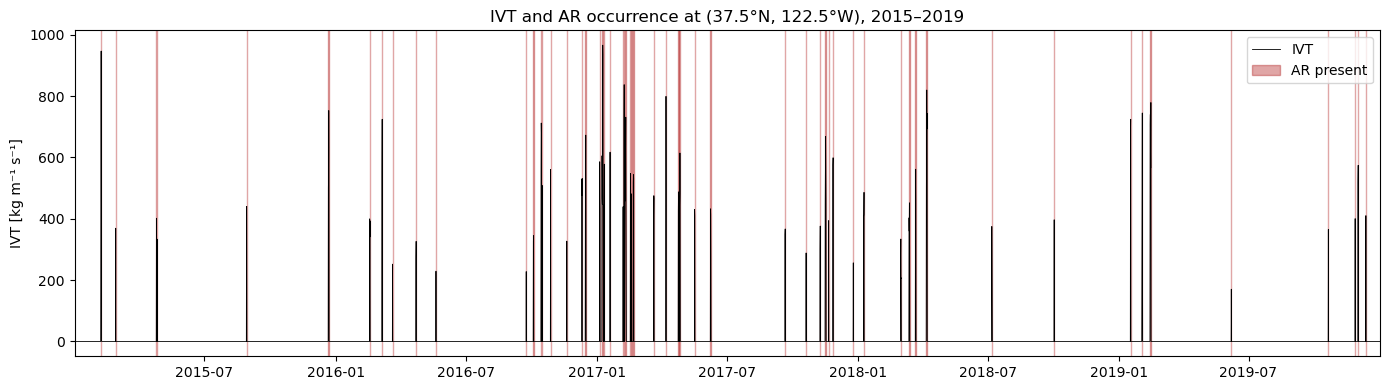

In [23]:
# Single grid cell near San Francisco
point = ds.sel(lat=37.5, lon=-122.5, method="nearest").sel(time=slice("2015", "2019"))
ivt_ts = point["ivt"].compute()
ar_ts  = point["ar_mask"].compute()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(ivt_ts.time, ivt_ts.values, color="black", lw=0.6, label="IVT")
ax.fill_between(
    ar_ts.time, 0, ivt_ts.values.max() * 1.05,
    where=ar_ts.values == 1, alpha=0.4, color="firebrick", label="AR present",
    transform=ax.get_xaxis_transform(),
)
ax.set_ylabel("IVT [kg m⁻¹ s⁻¹]")
ax.set_title(f"IVT and AR occurrence at (37.5°N, 122.5°W), 2015–2019")
ax.legend(loc="upper right")
ax.set_xlim(ivt_ts.time.min().values, ivt_ts.time.max().values)
plt.tight_layout()
plt.show()

You can see the **2016–2017 California winter storms** standing out — the back-to-back AR season that ended California's multi-year drought and triggered the Oroville Dam spillway crisis. Outside of AR periods, IVT mostly stays under ~300 kg m⁻¹ s⁻¹; during ARs it can spike above 800.

## 5. What fraction of extreme precipitation events are AR-driven?

A direct, policy-relevant question: for each grid cell, of all the extreme precipitation events that occurred, how many happened during an AR?

$$
\text{AR-attributable fraction} = \frac{\text{count}(\text{ar\_mask}=1 \,\text{AND}\, \text{epe\_p95}=1)}{\text{count}(\text{epe\_p95}=1)}
$$

This metric is between 0 and 1 (we'll plot it as a percentage). Values near 100% mean ARs are essentially the *only* cause of extreme precipitation at that cell. Values near 0% mean other mechanisms (ITCZ convection, monsoons, mesoscale convective systems, etc.) dominate the extremes.

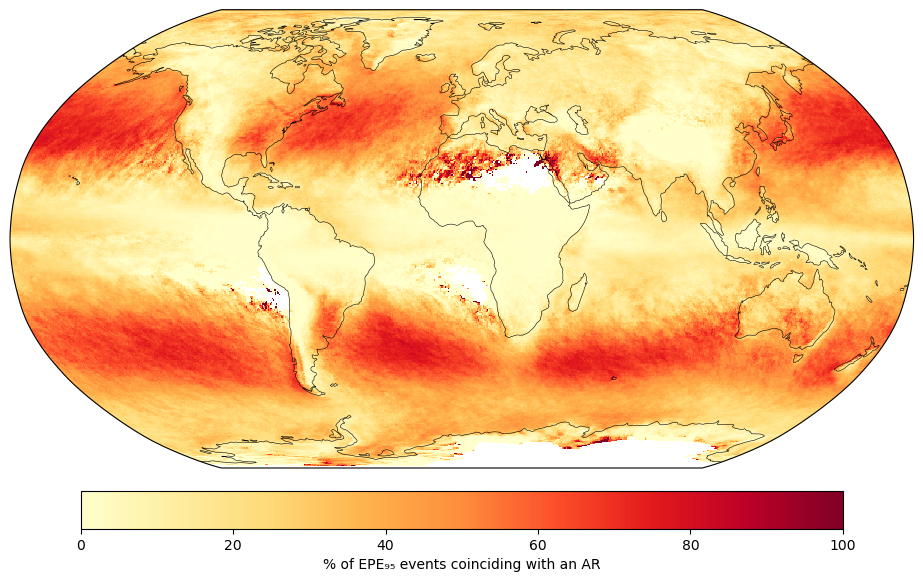

In [30]:
window = ds.sel(time=slice("2000", "2019"))
ar  = window["ar_mask"].astype(bool)
epe = window["epe_p95"].astype(bool)

# Numerator: timesteps where BOTH conditions are true
ar_and_epe = (ar & epe).sum(dim="time").compute()

# Denominator: total EPE events
n_epe = epe.sum(dim="time").compute()

# Fraction of extreme-precip events that coincided with an AR, in percent
ar_attrib = xr.where(n_epe > 0, ar_and_epe / n_epe, np.nan) * 100

fig, ax = plt.subplots(figsize=(13, 6), subplot_kw={"projection": ccrs.Robinson()})
im = ax.pcolormesh(
    ar_attrib.lon, ar_attrib.lat, ar_attrib.values,
    cmap="YlOrRd", shading="auto", 
    transform=ccrs.PlateCarree(),
)
ax.coastlines(linewidth=0.4, color="black")
ax.set_global()
plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.04, shrink=0.6,
             label="% of EPE₉₅ events coinciding with an AR")
plt.tight_layout()
plt.show()

Where the map is red, ARs strongly amplify extreme precipitation — the US West Coast, western Europe, Chile, New Zealand, the South Atlantic coast of Africa, and parts of East Asia all light up with lift values of 5–10× or higher. Over the open midlatitude oceans the lift is more modest (ARs are frequent but so are other heavy-precipitation drivers like extratropical cyclones), and in the tropics ARs are rare so the conditional probability is essentially undefined.

## 6. Where to go from here

A few directions, depending on your interest:

**Science cases** — AR science is comparably young and many questions are still unanswered, e.g., AR impacts at high latitudes and across other less-studied regions, compound & cascading AR risks, attribution of AR impacts in a changing climate, "tropical ARs", the vertical structure of ARs, interactions with other weather systems and AR forecasting. This list is far from complete. We hope that this openly available datacube can be a resource to tackle some of these research frontiers.


**Method development** — PIKART is one of several AR catalogs with global extent. Comparing detections across catalogs is an active research area; see the ARTMIP project (https://www.cgd.ucar.edu/projects/artmip/) for community-coordinated intercomparison.

**The companion Lagrangian product** — beyond this Eulerian (per-cell) view, PIKART also comprises Lagrangian AR trajectories as objects through time. See https://ar.pik-potsdam.de for that and other related products.

## Citation

If you use this dataset in published work, please cite:

> Vallejo-Bernal, S. M. & Braun, T., Marwan, N., & Kurths, J. (2025). PIKART: A comprehensive global catalog of atmospheric rivers. *Journal of Geophysical Research: Atmospheres*, 130, e2024JD041869. https://doi.org/10.1029/2024JD041869

and the most recent version the datacube is built on:
> Vallejo-Bernal, S., Braun, T., Marwan, N., & Kurths, J. (2026). *PIKART Version 1.1: Release Notes.* https://doi.org/10.31223/X5PB5Z

Finally, reference the EarthCODE entry for the datacube itself.